<h2>Importing Libraries</h2>

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

<h2>Loading Dataset</h2>

In [2]:
df = pd.read_csv("sales_data (1).csv")
df.head()

,Date,Product,Category,Region,Quantity,Sales($)
0,01-01-2021,Tablet,Mobile,Central,2,788.78
1,01-01-2021,Smartwatch,Wearables,East,1,235.63
2,02-01-2021,Keyboard,Accessories,South,1,64.06
3,03-01-2021,Webcam,Accessories,West,1,76.48
4,03-01-2021,Monitor,Computers,Central,1,337.47


<h2>Data Cleaning</h2>

In [3]:
df.describe(include='all')

,Date,Product,Category,Region,Quantity,Sales($)
count,5015,5015,5015,5015,5015.000000,4964.000000
unique,1716,10,5,5,NaN,NaN
top,22-04-2021,Smartphone,Accessories,South,NaN,NaN
freq,10,540,2032,1049,NaN,NaN
mean,NaN,NaN,NaN,NaN,3.098504,1011.282571
std,NaN,NaN,NaN,NaN,1.519146,1170.167897
min,NaN,NaN,NaN,NaN,1.000000,26.950000
25%,NaN,NaN,NaN,NaN,2.000000,258.300000
50%,NaN,NaN,NaN,NaN,3.000000,571.145000
75%,NaN,NaN,NaN,NaN,4.000000,1347.935000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5015 non-null   object 
 1   Product   5015 non-null   object 
 2   Category  5015 non-null   object 
 3   Region    5015 non-null   object 
 4   Quantity  5015 non-null   int64  
 5   Sales($)  4964 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 235.2+ KB


In [5]:
df.shape

(5015, 6)

In [6]:
#Checking for null values
df.isnull().sum()

Date         0
Product      0
Category     0
Region       0
Quantity     0
Sales($)    51
dtype: int64

In [7]:
#Removing null values
df['Sales($)'] = df['Sales($)'].fillna(df['Sales($)'].mean())

In [8]:
df.isnull().sum()

Date        0
Product     0
Category    0
Region      0
Quantity    0
Sales($)    0
dtype: int64

In [9]:
#Checking for duplicate values
df.duplicated().sum()

np.int64(15)

In [10]:
df[df.duplicated(keep=False)]

,Date,Product,Category,Region,Quantity,Sales($)
239,06-04-2021,Smartphone,Mobile,East,5,2768.85
240,06-04-2021,Smartphone,Mobile,East,5,2768.85
287,22-04-2021,Headphones,Accessories,Central,2,198.45
290,22-04-2021,Headphones,Accessories,Central,2,198.45
343,14-05-2021,Smartphone,Mobile,South,2,1257.96
345,14-05-2021,Smartphone,Mobile,South,2,1257.96
494,07-07-2021,Speaker,Audio,South,5,680.35
495,07-07-2021,Speaker,Audio,South,5,680.35
535,21-07-2021,Smartphone,Mobile,North,1,501.92
536,21-07-2021,Smartphone,Mobile,North,1,501.92


In [11]:
#Dropping Duplicates
df1 = df.drop_duplicates().copy()

In [12]:
df1.duplicated().sum()

np.int64(0)

In [13]:
df1 = df1.reset_index(drop=True).copy()

In [14]:
df1.head()

,Date,Product,Category,Region,Quantity,Sales($)
0,01-01-2021,Tablet,Mobile,Central,2,788.78
1,01-01-2021,Smartwatch,Wearables,East,1,235.63
2,02-01-2021,Keyboard,Accessories,South,1,64.06
3,03-01-2021,Webcam,Accessories,West,1,76.48
4,03-01-2021,Monitor,Computers,Central,1,337.47


<h2>Exploratory Data Analysis</h2>

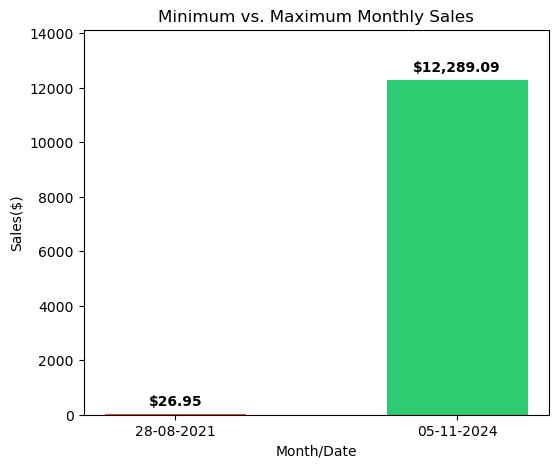

In [15]:
#Highest/Lowest Sales months
max_sales = df1['Sales($)'].max()
max_month = df1.loc[df1['Sales($)'].idxmax(),'Date']

min_sales = df1['Sales($)'].min()
min_month = df1.loc[df1['Sales($)'].idxmin(),'Date']

categories = [str(min_month), str(max_month)]
sales_values = [min_sales, max_sales]

plt.close('all')
plt.figure(figsize=(6,5))

bars = plt.bar(categories, sales_values, color=['#e74c3c','#2ecc71'], width=0.5)

# Add text labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    # Adjust 'va' (vertical alignment) and padding so text sits cleanly
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, f"${yval:,.2f}", 
             ha='center', va='bottom', fontweight='bold')


plt.xlabel('Month/Date')
plt.ylabel('Sales($)')
plt.title('Minimum vs. Maximum Monthly Sales')

# Extend the y-axis slightly so the text label doesn't get cut off at the top
plt.ylim(0, max(sales_values) * 1.15) 

plt.show()

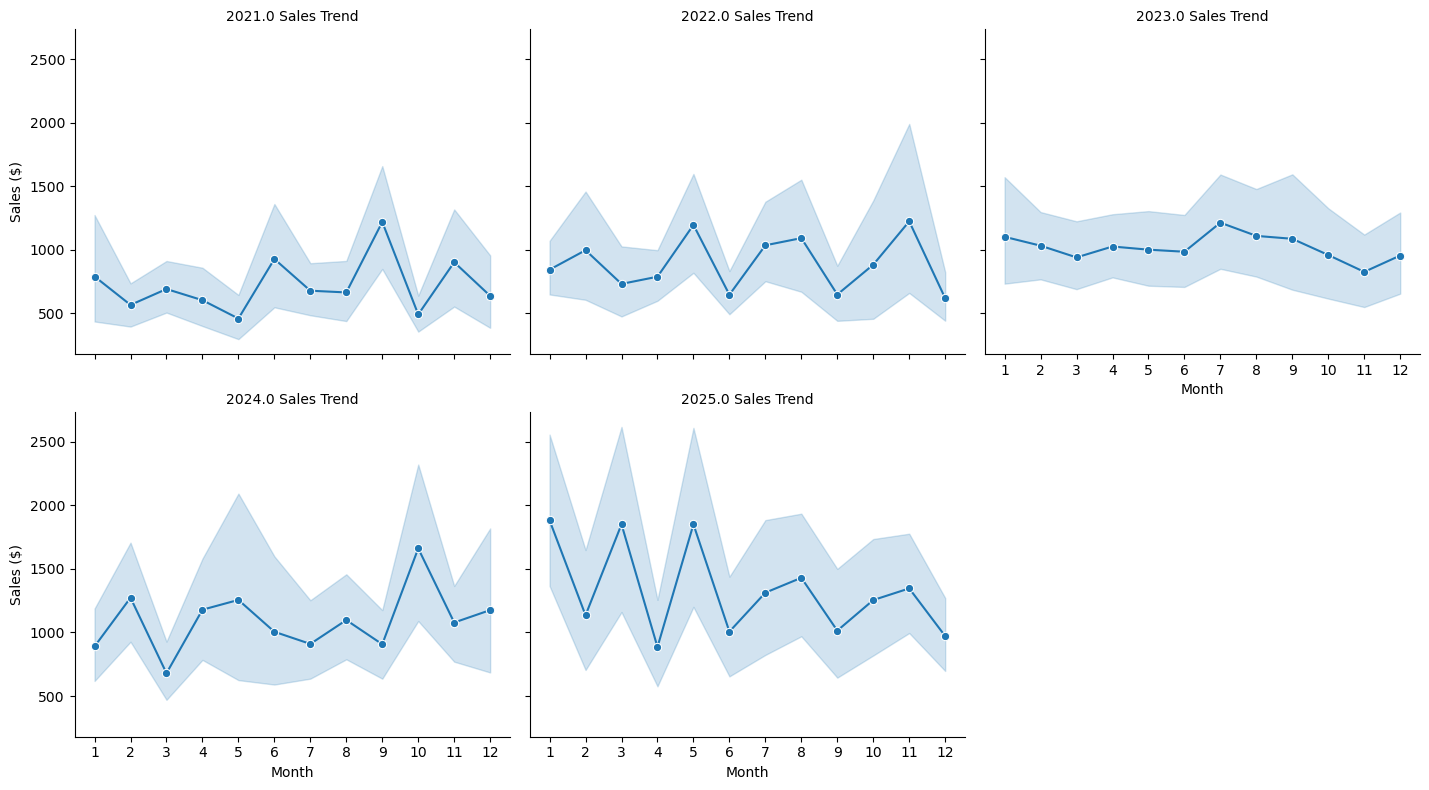

In [16]:
#Sales Trend over time(Month)
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month
df1['Day'] = df1['Date'].dt.day

# Ensure you are using clean data from your previous steps
plt.close('all')

# 'col=Year' splits the data into separate columns for each year
# 'col_wrap=3' means it will wrap to a new row after 3 charts side-by-side
g = sns.relplot(
    data=df1, 
    x='Month', 
    y='Sales($)', 
    col='Year', 
    kind='line', 
    marker='o',
    col_wrap=3, 
    height=4, 
    aspect=1.2,
    color='#1f77b4'
)

# Customizing axes labels across all subplots smoothly
g.set_axis_labels("Month", "Sales ($)")
g.set_titles("{col_name} Sales Trend")

# Force X-axis ticks to show all months (1-12) cleanly
for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))

plt.show()

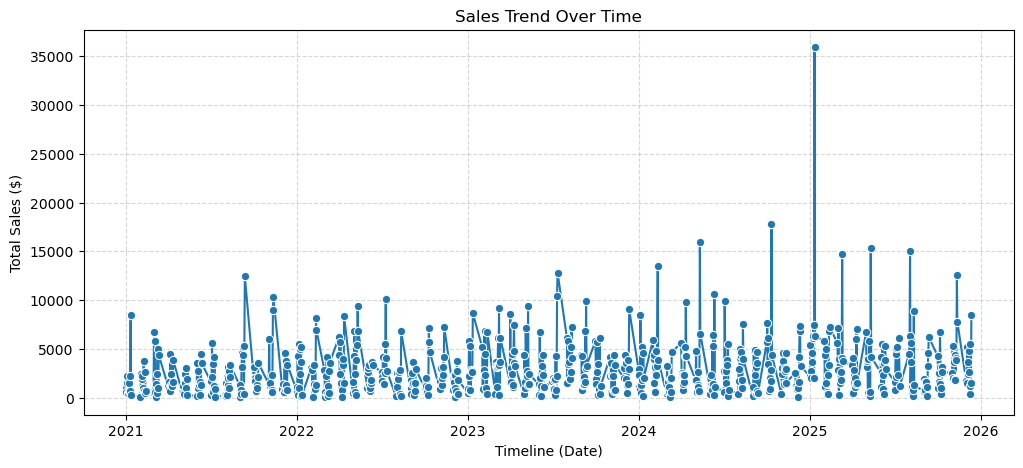

In [17]:
#Sales trend over time(Date)
plt.close('all')
plt.figure(figsize=(12, 5))

# Grouping by date ensures you look at the total sales timeline chronological order
# Change 'M' to 'D' for daily or 'W' for weekly depending on your data density
df_trend = df1.groupby('Date')['Sales($)'].sum().reset_index()

sns.lineplot(data=df_trend, x='Date', y='Sales($)', marker='o', color='#1f77b4')

plt.xlabel('Timeline (Date)')
plt.ylabel('Total Sales ($)')
plt.title('Sales Trend Over Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

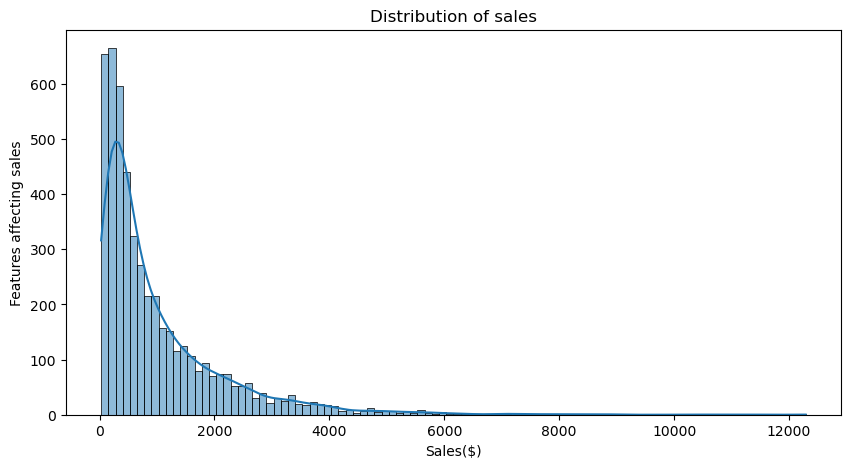

In [18]:
#Distribution of sales
plt.close('all')
plt.figure(figsize=(10,5))

sns.histplot(data=df1, x='Sales($)', kde=True)
plt.xlabel('Sales($)')
plt.ylabel('Features affecting sales')
plt.title(f"Distribution of sales")
plt.show()

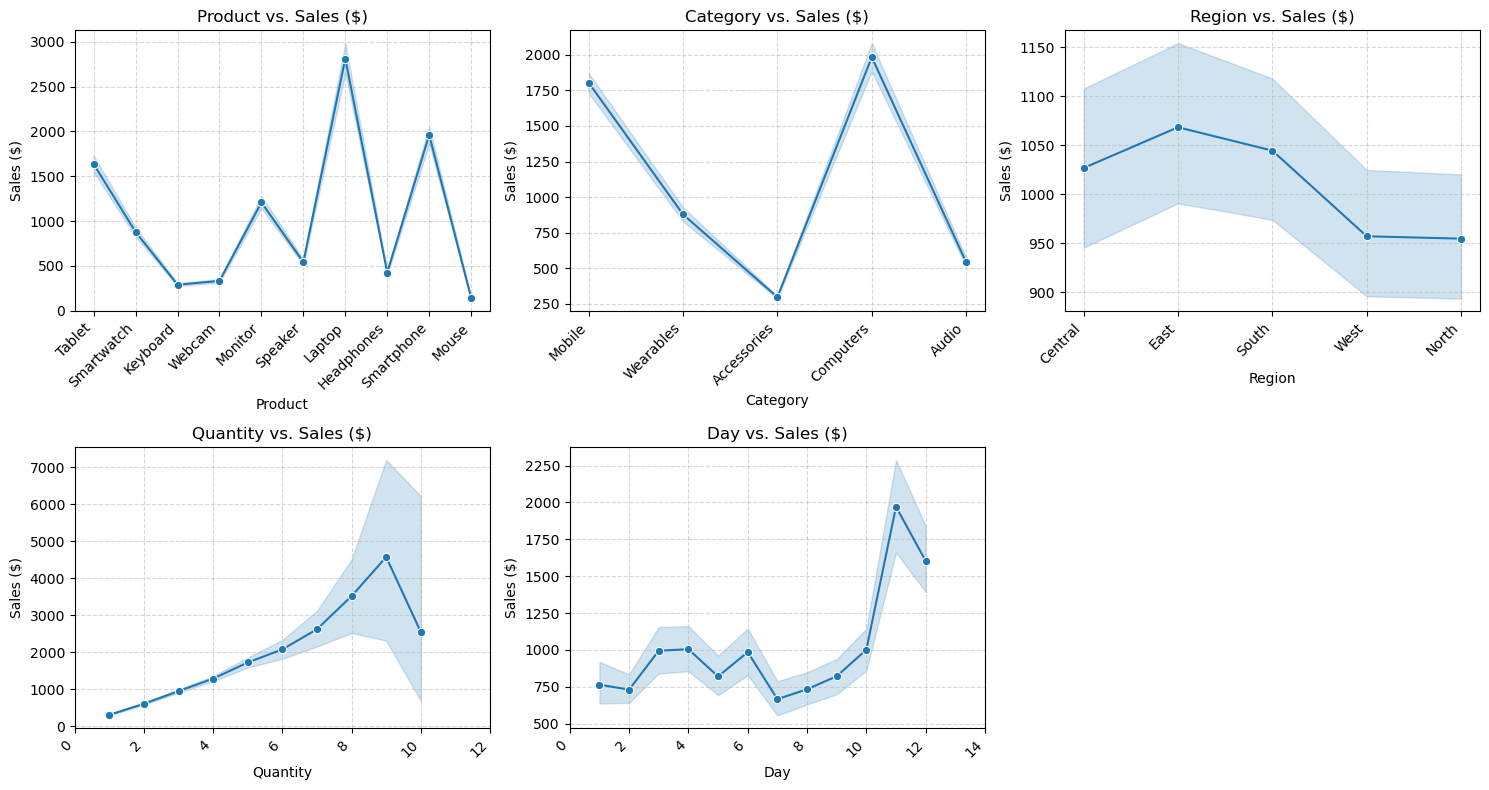

In [19]:
#Each graph for each feature and target variable
import math

plt.close('all')

# 1. Isolate your features
df2 = df1.drop(['Sales($)','Date','Month','Year'], axis='columns')
columns_to_plot = df2.columns
num_plots = len(columns_to_plot)

# 2. Configure the grid structure
num_cols = 3  # Change this to 2 or 4 depending on your screen size
num_rows = math.ceil(num_plots / num_cols)

# 3. Initialize the grid figure
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))

# Flatten the axes array to make indexing simple in a single loop
axes = axes.flatten()

# 4. Loop through features and assign each to a specific subplot axis (ax)
for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    
    # Notice we explicitly tell Seaborn WHICH subplot to use with 'ax=ax'
    sns.lineplot(data=df1, x=col, y='Sales($)', marker='o', ax=ax)
    
    # Apply labels individually to each subplot
    ax.set_xlabel(col)
    ax.set_ylabel('Sales ($)')
    ax.set_title(f"{col} vs. Sales ($)")
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Clean up overlapping text if your X-axis contains long text (like product names)
    if df1[col].dtype == 'object' or len(df1[col].unique()) > 5:
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# 5. Hide any unused empty subplot slots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing so titles and labels don't crash into each other
plt.tight_layout()
plt.show()

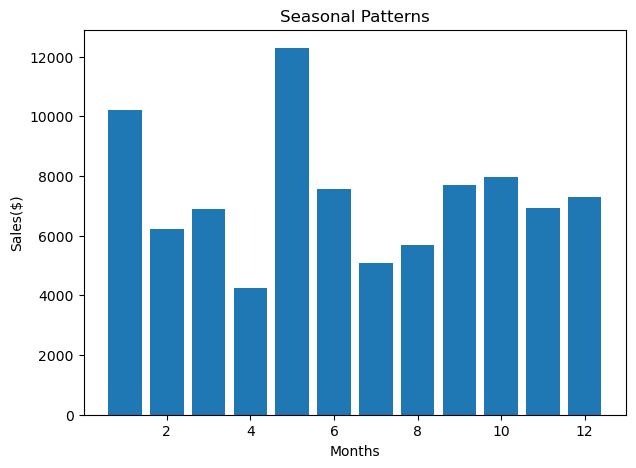

In [20]:
#Seasonal Patterns
plt.figure(figsize=(7,5))

plt.bar(df1['Month'],df1['Sales($)'])

plt.title('Seasonal Patterns')
plt.xlabel('Months')
plt.ylabel('Sales($)')
plt.show()

<h2>Feature Engineering</h2>

In [21]:
#Checking for value counts in every feature
features = ['Product','Category','Region','Quantity','Month','Year','Day']

for feature in features:
    print(df1[feature].value_counts())

Product
Smartphone    536
Mouse         524
Keyboard      516
Speaker       502
Headphones    498
Monitor       493
Tablet        492
Smartwatch    489
Webcam        488
Laptop        462
Name: count, dtype: int64
Category
Accessories    2026
Mobile         1028
Computers       955
Audio           502
Wearables       489
Name: count, dtype: int64
Region
South      1046
West       1017
North       986
Central     983
East        968
Name: count, dtype: int64
Quantity
3     1359
2     1145
4      930
1      742
5      480
6      214
7       90
8       26
9       11
10       3
Name: count, dtype: int64
Month
4.0     194
1.0     170
2.0     165
3.0     165
12.0    165
8.0     158
11.0    157
7.0     157
10.0    153
5.0     153
6.0     152
9.0     147
Name: count, dtype: int64
Year
2023.0    424
2021.0    382
2024.0    380
2025.0    378
2022.0    372
Name: count, dtype: int64
Day
2.0     190
11.0    173
10.0    173
1.0     171
8.0     169
9.0     168
7.0     161
3.0     159
12.0    154
4.0 

In [22]:
#Converting every category above 7 to 7 in Quantity feature 
df1['Quantity'] = df1['Quantity'].apply(lambda x: 7 if x>=7 else x)

In [23]:
df1.head()

,Date,Product,Category,Region,Quantity,Sales($),Year,Month,Day
0,2021-01-01,Tablet,Mobile,Central,2,788.78,2021.0,1.0,1.0
1,2021-01-01,Smartwatch,Wearables,East,1,235.63,2021.0,1.0,1.0
2,2021-02-01,Keyboard,Accessories,South,1,64.06,2021.0,2.0,1.0
3,2021-03-01,Webcam,Accessories,West,1,76.48,2021.0,3.0,1.0
4,2021-03-01,Monitor,Computers,Central,1,337.47,2021.0,3.0,1.0


In [24]:
#Dropping Date axis
df2 = df1.drop('Date',axis=1).copy()

In [25]:
df2.dtypes

Product      object
Category     object
Region       object
Quantity      int64
Sales($)    float64
Year        float64
Month       float64
Day         float64
dtype: object

<h2>Data Preprocessing</h2>

In [26]:
#Create function build_pipeline to preprocess features
def build_pipeline(num_att, cat_att):
    num_pipeline = Pipeline([
        ('imputer',SimpleImputer(strategy = 'mean')),
        ('scaler',StandardScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer',SimpleImputer(strategy = 'most_frequent')),
        ('oe',OrdinalEncoder(handle_unknown='use_encoded_value',
            unknown_value=-1))
    ])
    full_pipeline = ColumnTransformer([
        ('num',num_pipeline,num_att),
        ('cat',cat_pipeline,cat_att)
    ])
    return full_pipeline

In [27]:
#Outlier removal using z_score function
def remove_outliers_zscore(df, threshold=3):
    df_clean = df.copy()
    
    # Iterate through all columns
    for col in df_clean.columns:
        # Check if the column is numeric
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col] = pd.to_numeric(df_clean[col],errors='coerce')
            col_mean = df_clean[col].mean()
            col_std = df_clean[col].std()
            
            # Avoid division by zero if std deviation is 0
            if col_std == 0:
                continue
                
            z_scores = np.abs((df_clean[col] - col_mean) / col_std)
            
            # Keep rows where the z-score is less than the threshold
            outliers_condition = z_scores < threshold
            outliers_removed = len(df_clean) - outliers_condition.sum()
            
            df_clean = df_clean[outliers_condition]
            
            print(f"Processing Column: {col}")
            print(f"Total outliers detected and removed: {outliers_removed}")
            print(f"Number of rows remaining: {len(df_clean)}")
            print("-" * 40)
            
    return df_clean

<h2>Train Test Split</h2>

In [28]:
X = df2.drop('Sales($)',axis='columns')
y = df2['Sales($)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= pd.cut(y, 5))

In [29]:
#Calling function build pipeline 
num_att = X_train.select_dtypes(['int64','float64']).columns.tolist()
cat_att = X_train.select_dtypes(['object','category']).columns.tolist()

all_cols = num_att + cat_att

preprocessor = build_pipeline(num_att, cat_att)

#use Fit_transform on X_train 
X_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), columns=all_cols).round(2)

#Use transform function on X_test to avoid data leakage
X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), columns=all_cols)

In [30]:
X_scaled.head()

,Quantity,Year,Month,Day,Product,Category,Region
0,-0.73,0.00,0.00,0.00,5.0,3.0,3.0
1,1.31,0.00,0.00,0.00,2.0,2.0,1.0
2,-0.73,-2.29,0.73,-1.61,8.0,3.0,0.0
3,-0.05,2.34,-1.11,2.49,1.0,0.0,3.0
4,0.63,-1.13,1.65,-0.69,6.0,4.0,4.0


In [31]:
#Call Remove outlier function to clean X_scales
X_clean = remove_outliers_zscore(X_scaled)

Processing Column: Quantity
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------
Processing Column: Year
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------
Processing Column: Month
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------
Processing Column: Day
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------
Processing Column: Product
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------
Processing Column: Category
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------
Processing Column: Region
Total outliers detected and removed: 0
Number of rows remaining: 4000
----------------------------------------


In [32]:
X_clean.head()

,Quantity,Year,Month,Day,Product,Category,Region
0,-0.73,0.00,0.00,0.00,5.0,3.0,3.0
1,1.31,0.00,0.00,0.00,2.0,2.0,1.0
2,-0.73,-2.29,0.73,-1.61,8.0,3.0,0.0
3,-0.05,2.34,-1.11,2.49,1.0,0.0,3.0
4,0.63,-1.13,1.65,-0.69,6.0,4.0,4.0


In [33]:
print(f"X_clean shape: {X_clean.shape}")
print(f"y_train shape: {y_train.shape}")

print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

X_clean shape: (4000, 7)
y_train shape: (4000,)
X_test shape: (1000, 7)
y_test shape: (1000,)


<h2>EDA on Train Data</h2>

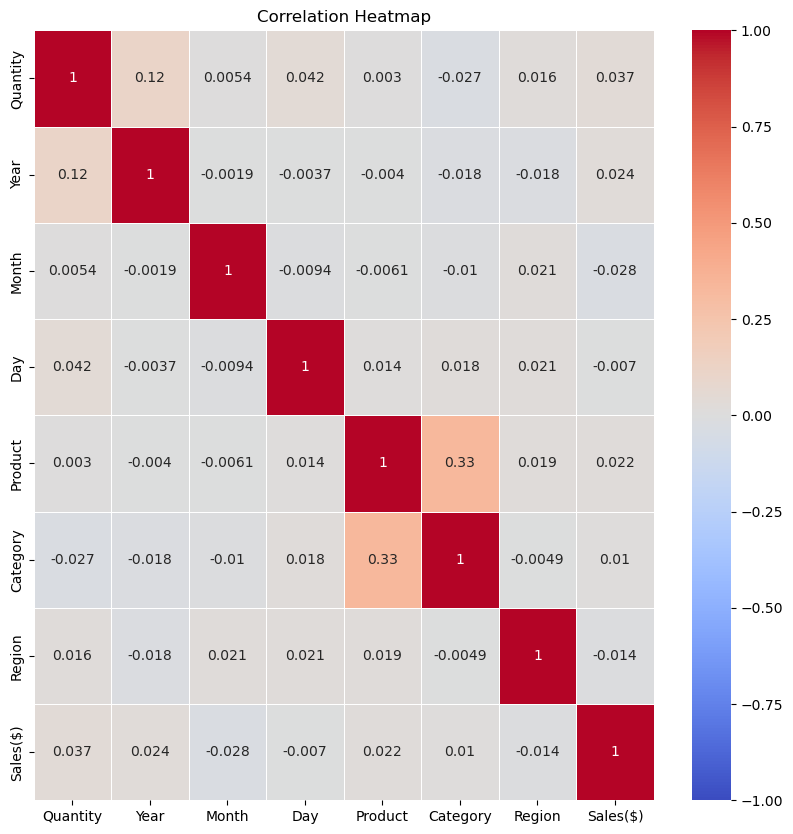

In [34]:
plt.figure(figsize=(10,10))

numeric_df = pd.concat([X_clean, y_train],axis=1)

cor_values = numeric_df.corr(method='spearman')
sns.heatmap(cor_values, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap')
plt.show()

<h2>Model Building</h2>

In [35]:
model_params = {
    'Linear_Regression' : {
        'model' : LinearRegression(),
        'params' : {
            'fit_intercept' : [True, False]
        }
    },

    'Random_Forest' : {
        'model' : RandomForestRegressor(random_state=42),
        'params' : {
            'n_estimators'     : [100, 175, 250],
            'max_depth'        : [10, 20, None],
            'min_samples_split': [2, 20, 50],
        }
    },

    'Decision Tree':{
        'model' : DecisionTreeRegressor(random_state=42),
        'params':{
            'max_depth' : [1,5,10]
        } 
     }
}

In [36]:
#Use Grid Search CV to find best model with best params and r2 score(Hyper Parameter Tuning)
scores = []

for model, mp in model_params.items():
    gs = GridSearchCV(mp['model'],mp['params'], cv=5, scoring='r2', n_jobs = -1, verbose = 1)
    gs.fit(X_clean, y_train)
    scores.append({
    'Model' : model,
    'best_score' : gs.best_score_,
    'best_param' : gs.best_params_
    })

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [37]:
pd.set_option('display.max_colwidth',None)
result = pd.DataFrame(scores, columns=['Model','best_score','best_param'])
result

,Model,best_score,best_param
0,Linear_Regression,0.494122,{'fit_intercept': True}
1,Random_Forest,0.924337,"{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 250}"
2,Decision Tree,0.903872,{'max_depth': 10}


<h3>Choose Best Model that is Random Forest</h3>

In [38]:
model = RandomForestRegressor(max_depth= 10, min_samples_split=2, n_estimators=250, random_state=42)
model.fit(X_clean, y_train)

RandomForestRegressor(max_depth=10, n_estimators=250, random_state=42)

In [39]:
y_pred = model.predict(X_test_scaled)

In [40]:
# 2. Create a clean pandas DataFrame for your new single row of raw data
# (Note: Match the exact column names you used to train your model)
new_data = pd.DataFrame([{
    'Quantity': 2,
    'Year': 2023, 
    'Month': 5,
    'Day': 30,
    'Product': 'Smartwatch',
    'Category': 'Wearables' # Add the rest of your columns here exactly as they appear in X
}], columns=X_clean.columns) # Safely aligns column order automatically

# 3. Step A: Preprocess the raw features
new_data_scaled = pd.DataFrame(preprocessor.transform(new_data), columns=X_clean.columns)

# 4. Step B: Feed the scaled features to the model to get the forecast
future_sales = model.predict(new_data_scaled)

print(f"Future sales for next 30 days: ${future_sales[0]:.2f}")

Future sales for next 30 days: $670.86


<h2>Evaluation</h2>

In [41]:
print(f"Model Accuracy : {r2_score(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred)}")

Model Accuracy : 0.9132850897316037
MAE : 163.91213885621727
RMSE : 341.5464268831273


<h2>Compare Actual vs Predicted values</h2>

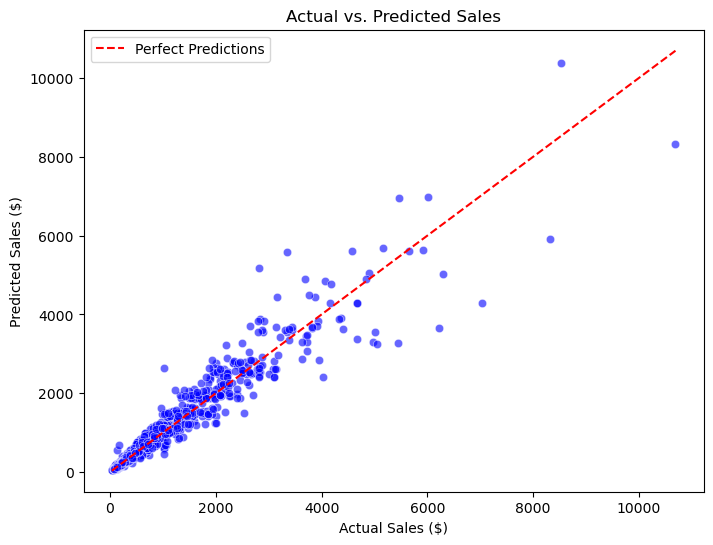

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='b')

perfect_line = [min(y_test), max(y_test)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Perfect Predictions')

plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title('Actual vs. Predicted Sales')
plt.legend()
plt.show()